In [1]:
# =========================================================
# Day 5. 시계열 분석과 예지보전 실습
# 실제 업로드 파일 기준: labeled_data.csv
#
# 목표
# 1) TimeStamp 기반 시계열 구조 이해
# 2) 시계열 EDA
# 3) rolling / lag feature 생성
# 4) 시간순 train/test split
# 5) ML 기반 시계열 예측
# 6) PassOrFail를 활용한 이상징후 구간 해석
# =========================================================

In [2]:
# ---------------------------------------------------------
# 1. 라이브러리 불러오기
# ---------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
# ---------------------------------------------------------
# 2. 기본 설정
# ---------------------------------------------------------
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
np.random.seed(42)

In [4]:
# ---------------------------------------------------------
# 3. 데이터 불러오기
# ---------------------------------------------------------
file_path = "labeled_data.csv"
df = pd.read_csv(file_path)

print("=== 원본 데이터 상위 5행 ===")
display(df.head())

=== 원본 데이터 상위 5행 ===


,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
print("=== 데이터 크기 ===")
print(df.shape)

=== 데이터 크기 ===
(7996, 45)


In [6]:
print("=== 컬럼 목록 ===")
print(df.columns.tolist())

=== 컬럼 목록 ===
['_id', 'TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD', 'EQUIP_NAME', 'PassOrFail', 'Reason', 'Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3', 'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12']


In [7]:
print("=== 데이터 정보 ===")
df.info()

=== 데이터 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7996 entries, 0 to 7995
Data columns (total 45 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   _id                       7996 non-null   object 
 1   TimeStamp                 7996 non-null   object 
 2   PART_FACT_PLAN_DATE       7996 non-null   object 
 3   PART_FACT_SERIAL          7996 non-null   int64  
 4   PART_NAME                 7996 non-null   object 
 5   EQUIP_CD                  7996 non-null   object 
 6   EQUIP_NAME                7996 non-null   object 
 7   PassOrFail                7996 non-null   object 
 8   Reason                    71 non-null     object 
 9   Injection_Time            7996 non-null   float64
 10  Filling_Time              7996 non-null   float64
 11  Plasticizing_Time         7996 non-null   float64
 12  Cycle_Time                7996 non-null   float64
 13  Clamp_Close_Time          7996 non-null   float6

In [8]:
# ---------------------------------------------------------
# 4. TimeStamp 처리
# ---------------------------------------------------------
df["TimeStamp"] = pd.to_datetime(df["TimeStamp"], errors="coerce")

print("=== TimeStamp 결측 개수 ===")
print(df["TimeStamp"].isna().sum())

=== TimeStamp 결측 개수 ===
0


In [9]:
# TimeStamp 없는 행 제거
df = df.dropna(subset=["TimeStamp"]).copy()

In [10]:
# 시간순 정렬
df = df.sort_values("TimeStamp").reset_index(drop=True)

In [11]:
print("=== 정렬 후 TimeStamp 범위 ===")
print(df["TimeStamp"].min(), "to", df["TimeStamp"].max())

=== 정렬 후 TimeStamp 범위 ===
2020-10-16 04:57:47 to 2020-11-06 04:27:38


In [12]:
# ---------------------------------------------------------
# 5. PassOrFail 처리
#    - Y/N -> 0/1 로 변환
#    - Y: 정상, N: 불량 으로 가정
# ---------------------------------------------------------
df["PassOrFail_binary"] = df["PassOrFail"].map({"Y": 0, "N": 1})

print("=== PassOrFail 분포 ===")
display(df["PassOrFail"].value_counts(dropna=False))

=== PassOrFail 분포 ===


PassOrFail
Y    7925
N      71
Name: count, dtype: int64

In [13]:
print("=== PassOrFail_binary 분포 ===")
display(df["PassOrFail_binary"].value_counts(dropna=False))

=== PassOrFail_binary 분포 ===


PassOrFail_binary
0    7925
1      71
Name: count, dtype: int64

In [14]:
# ---------------------------------------------------------
# 6. 분석에 불필요한 ID/문자 컬럼 정리
# ---------------------------------------------------------
drop_cols_base = [
    "_id",
    "PART_FACT_PLAN_DATE",
    "PART_FACT_SERIAL",
    "PART_NAME",
    "EQUIP_CD",
    "EQUIP_NAME",
    "PassOrFail",
    "Reason"
]

existing_drop_cols = [col for col in drop_cols_base if col in df.columns]
df_model = df.drop(columns=existing_drop_cols).copy()

print("=== 분석용 데이터 상위 5행 ===")
display(df_model.head())

=== 분석용 데이터 상위 5행 ===


,TimeStamp,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12,PassOrFail_binary
0,2020-10-16 04:57:47,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.5,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2020-10-16 04:58:48,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,2020-10-16 04:58:48,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.5,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,2020-10-16 04:59:48,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,2020-10-16 04:59:48,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.5,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [15]:
# ---------------------------------------------------------
# 7. 회귀 타깃 설정
#    - 시계열 예측 대상: Cycle_Time
#    - 이유: 공정 전체 시간이라 직관적이고 해석이 쉬움
# ---------------------------------------------------------
target_col = "Cycle_Time"

print("=== 회귀 타깃 ===")
print("target_col =", target_col)

=== 회귀 타깃 ===
target_col = Cycle_Time


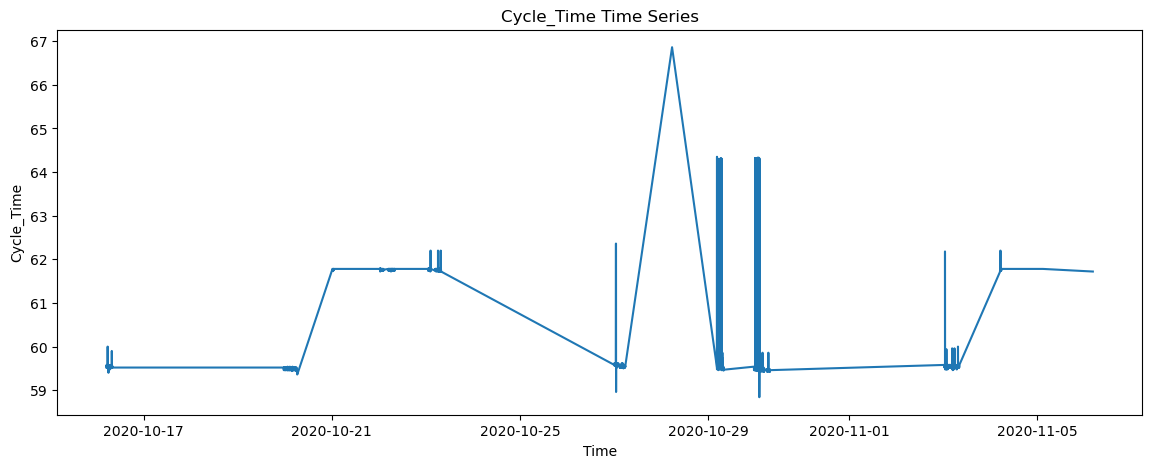

In [16]:
# ---------------------------------------------------------
# 8. 시계열 EDA - 기본 그래프
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(df_model["TimeStamp"], df_model[target_col])
plt.title(f"{target_col} Time Series")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.show()

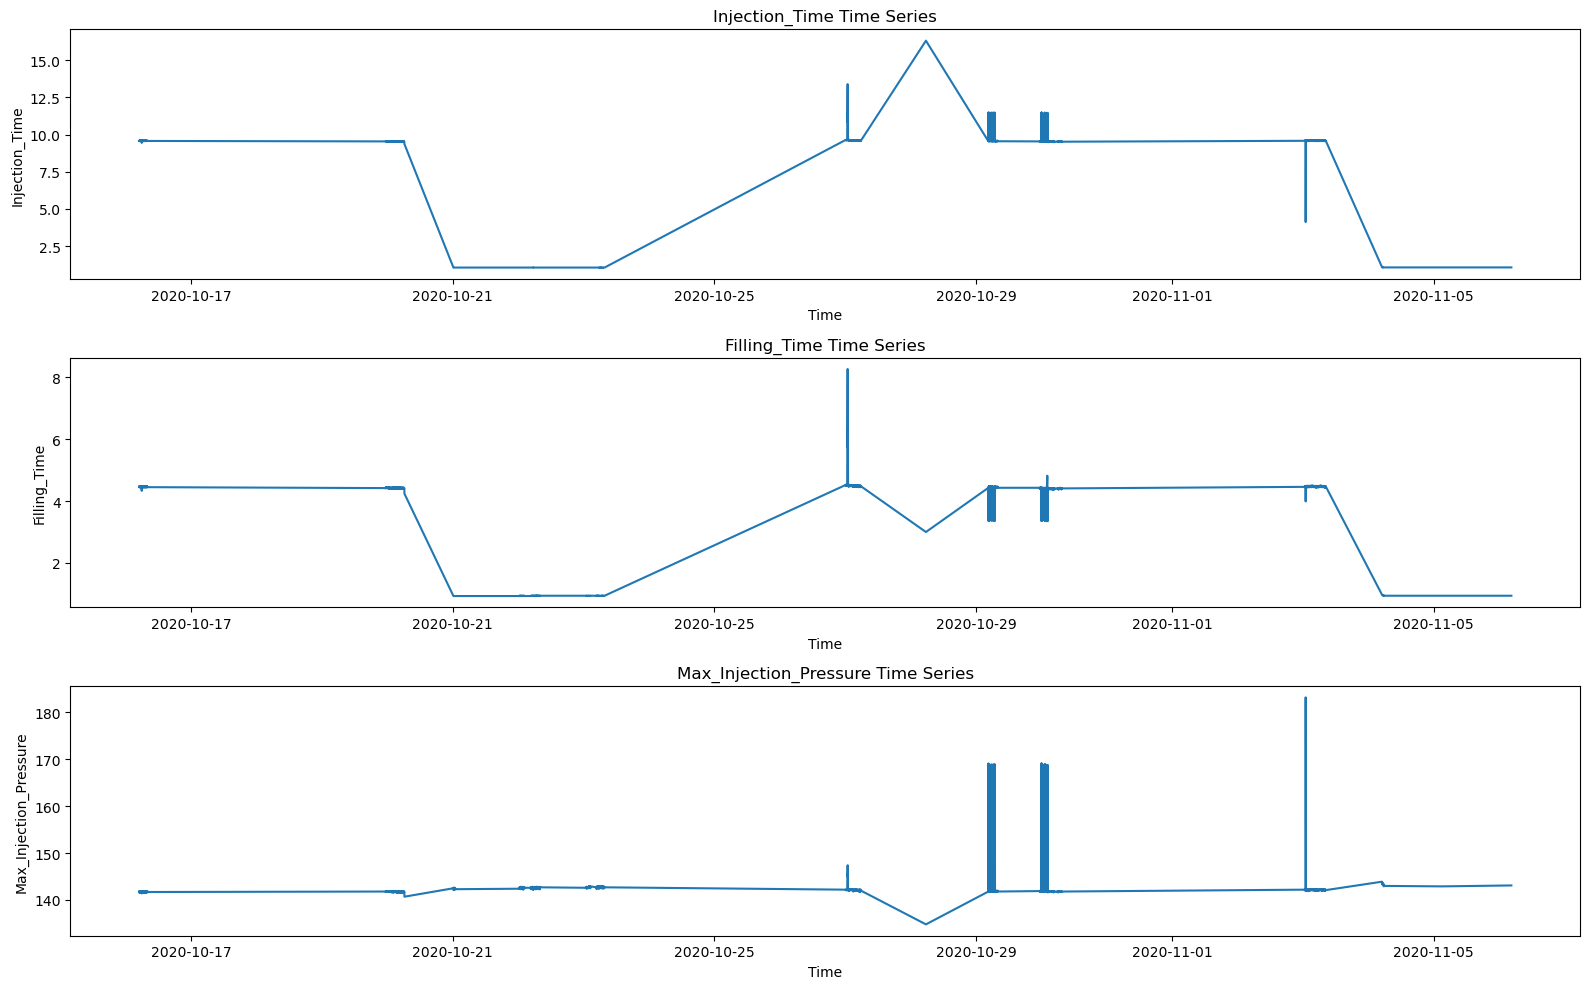

In [17]:
# 보조 변수 3개 보기
sensor_cols = ["Injection_Time", "Filling_Time", "Max_Injection_Pressure"]

plt.figure(figsize=(16, 10))

for i, col in enumerate(sensor_cols, 1):
    plt.subplot(3, 1, i)
    plt.plot(df_model["TimeStamp"], df_model[col])
    plt.title(f"{col} Time Series")
    plt.xlabel("Time")
    plt.ylabel(col)

plt.tight_layout()
plt.show()

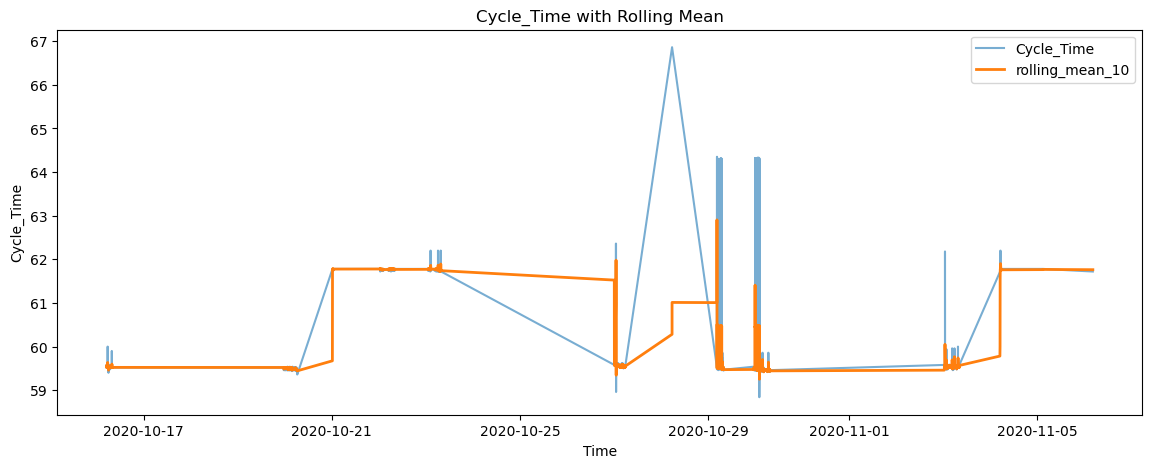

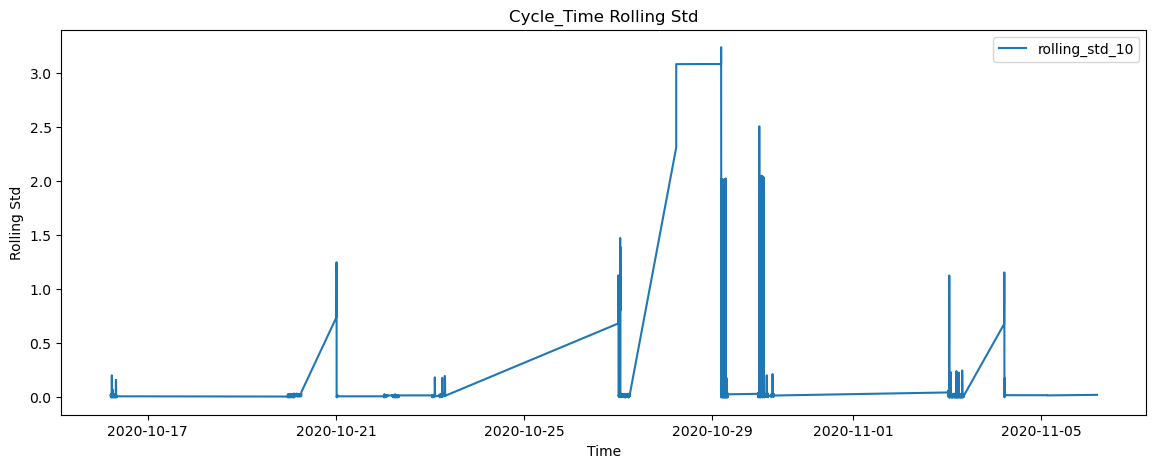

In [18]:
# ---------------------------------------------------------
# 9. rolling mean / rolling std
# ---------------------------------------------------------
df_model["rolling_mean_10"] = df_model[target_col].rolling(window=10).mean()
df_model["rolling_std_10"] = df_model[target_col].rolling(window=10).std()

plt.figure(figsize=(14, 5))
plt.plot(df_model["TimeStamp"], df_model[target_col], label=target_col, alpha=0.6)
plt.plot(df_model["TimeStamp"], df_model["rolling_mean_10"], label="rolling_mean_10", linewidth=2)
plt.title(f"{target_col} with Rolling Mean")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df_model["TimeStamp"], df_model["rolling_std_10"], label="rolling_std_10")
plt.title(f"{target_col} Rolling Std")
plt.xlabel("Time")
plt.ylabel("Rolling Std")
plt.legend()
plt.show()

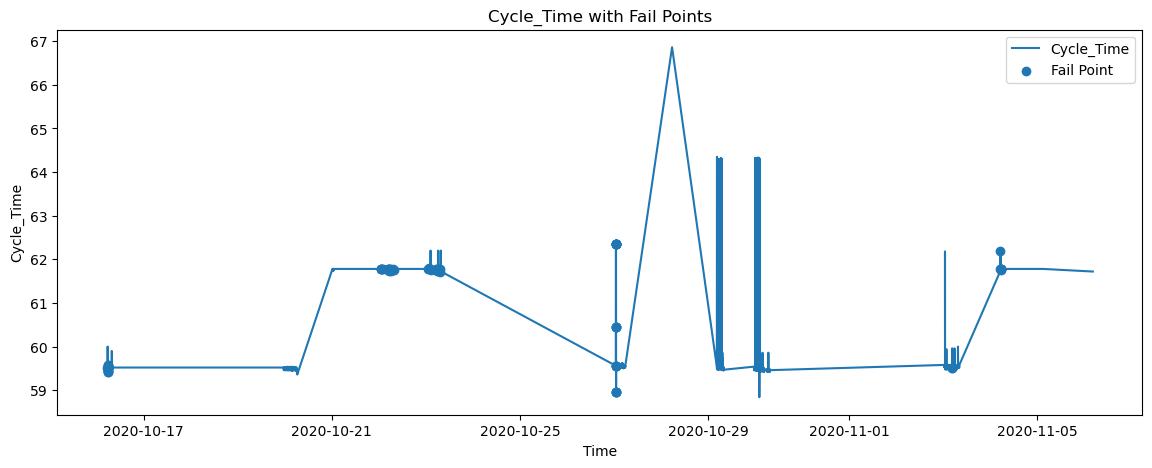

In [19]:
# ---------------------------------------------------------
# 10. PassOrFail 발생 시점 표시
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(df_model["TimeStamp"], df_model[target_col], label=target_col)

fail_points = df_model[df_model["PassOrFail_binary"] == 1]
plt.scatter(
    fail_points["TimeStamp"],
    fail_points[target_col],
    label="Fail Point",
    marker="o"
)

plt.title(f"{target_col} with Fail Points")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.show()

=== 시간 간격 기초 통계 ===


count      7995.000000
mean        226.715572
std        6660.905886
min           0.000000
25%           0.000000
50%           0.000000
75%          59.000000
max      320530.000000
Name: time_diff_sec, dtype: float64

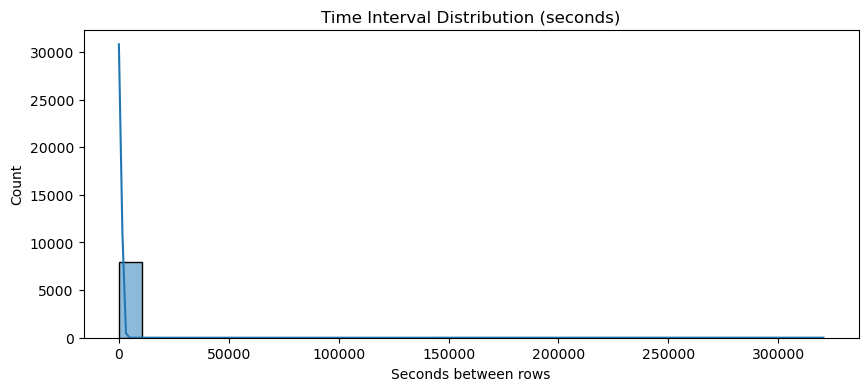

In [20]:
# ---------------------------------------------------------
# 11. 시간 간격 확인
# ---------------------------------------------------------
df_model["time_diff_sec"] = df_model["TimeStamp"].diff().dt.total_seconds()

print("=== 시간 간격 기초 통계 ===")
display(df_model["time_diff_sec"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df_model["time_diff_sec"].dropna(), bins=30, kde=True)
plt.title("Time Interval Distribution (seconds)")
plt.xlabel("Seconds between rows")
plt.show()

In [21]:
# ---------------------------------------------------------
# 12. 시계열용 feature engineering
#    - lag / rolling / 시간 파생변수
# ---------------------------------------------------------
df_feat = df_model.copy()

# lag features
df_feat["lag_1"] = df_feat[target_col].shift(1)
df_feat["lag_3"] = df_feat[target_col].shift(3)
df_feat["lag_5"] = df_feat[target_col].shift(5)
df_feat["lag_10"] = df_feat[target_col].shift(10)

# rolling features
df_feat["rolling_mean_3"] = df_feat[target_col].shift(1).rolling(3).mean()
df_feat["rolling_mean_5"] = df_feat[target_col].shift(1).rolling(5).mean()
df_feat["rolling_mean_10"] = df_feat[target_col].shift(1).rolling(10).mean()
df_feat["rolling_std_5"] = df_feat[target_col].shift(1).rolling(5).std()
df_feat["rolling_std_10"] = df_feat[target_col].shift(1).rolling(10).std()

# 시간 파생변수
df_feat["hour"] = df_feat["TimeStamp"].dt.hour
df_feat["minute"] = df_feat["TimeStamp"].dt.minute
df_feat["dayofweek"] = df_feat["TimeStamp"].dt.dayofweek

print("=== feature engineering 후 상위 10행 ===")
display(df_feat.head(10))

=== feature engineering 후 상위 10행 ===


,TimeStamp,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Switch_Over_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,Max_Screw_RPM,Average_Screw_RPM,Max_Injection_Pressure,Max_Switch_Over_Pressure,Max_Back_Pressure,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Barrel_Temperature_7,Hopper_Temperature,Mold_Temperature_1,Mold_Temperature_2,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12,PassOrFail_binary,rolling_mean_10,rolling_std_10,time_diff_sec,lag_1,lag_3,lag_5,lag_10,rolling_mean_3,rolling_mean_5,rolling_std_5,hour,minute,dayofweek
0,2020-10-16 04:57:47,9.59,4.47,16.92,59.520000,7.13,653.409973,0.0,68.849998,647.98999,55.400002,30.700001,292.500000,141.800003,136.800003,37.400002,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,0.0,66.300003,0.0,0.0,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,57,4
1,2020-10-16 04:58:48,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,61.0,59.520000,NaN,NaN,NaN,NaN,NaN,NaN,4,58,4
2,2020-10-16 04:58:48,9.60,4.48,16.91,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.299999,30.799999,292.500000,141.800003,136.899994,37.500000,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,0.0,67.199997,0.0,0.0,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0.0,59.580002,NaN,NaN,NaN,NaN,NaN,NaN,4,58,4
3,2020-10-16 04:59:48,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,60.0,59.580002,59.520000,NaN,NaN,59.560001,NaN,NaN,4,59,4
4,2020-10-16 04:59:48,9.59,4.48,16.91,59.560001,7.13,653.419983,0.0,68.839996,647.98999,55.299999,31.000000,292.500000,141.800003,136.800003,37.500000,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,0.0,66.900002,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0.0,59.560001,59.580002,NaN,NaN,59.573335,NaN,NaN,4,59,4
5,2020-10-16 05:00:46,9.58,4.46,16.90,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,0.0,67.500000,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,58.0,59.560001,59.580002,59.520000,NaN,59.566668,59.560001,0.024495,5,0,4
6,2020-10-16 05:00:46,9.58,4.46,16.90,59.580002,7.13,653.409973,0.0,68.839996,647.98999,55.599998,30.900000,292.500000,141.699997,136.399994,37.700001,59.400002,276.299988,275.299988,275.200012,271.399994,255.000000,230.000000,0.0,67.500000,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,0.0,59.580002,59.560001,59.580002,NaN,59.566668,59.572002,0.010955,5,0,4
7,2020-10-16 05:01:46,9.58,4.46,16.92,59.560001,7.13,653.409973,0.0,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,0.0,67.000000,0.0,0.0,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,NaN,NaN,60.0,59.580002,59.560001,59.580002,NaN,59.573335,59.572002,0.010955,5,1,4
8,2020-10-16 05:01:46,9.58,4.46,16.92,59.560001,7.13,653.409973,0.0,68.849998,647.98999,55.500000,30.600000,292.399994,141.800003,136.699997,37.400002,59.299999,275.799988,275.399994,275.000000,271.299988,255.000000,230.000000,0.0

In [22]:
# ---------------------------------------------------------
# 13. 모델 입력 컬럼 선택
#    - 타깃 누수 방지: target_col 자체는 입력에서 제외
# ---------------------------------------------------------
exclude_cols = ["TimeStamp", target_col]

feature_cols = [
    col for col in df_feat.columns
    if col not in exclude_cols
]

print("\n=== 입력 feature 개수 ===")
print(len(feature_cols))

print("\n=== 입력 feature 목록 ===")
print(feature_cols)


=== 입력 feature 개수 ===
49

=== 입력 feature 목록 ===
['Injection_Time', 'Filling_Time', 'Plasticizing_Time', 'Clamp_Close_Time', 'Cushion_Position', 'Switch_Over_Position', 'Plasticizing_Position', 'Clamp_Open_Position', 'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM', 'Max_Injection_Pressure', 'Max_Switch_Over_Pressure', 'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1', 'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4', 'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Barrel_Temperature_7', 'Hopper_Temperature', 'Mold_Temperature_1', 'Mold_Temperature_2', 'Mold_Temperature_3', 'Mold_Temperature_4', 'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'PassOrFail_binary', 'rolling_mean_10', 'rolling_std_10', 'time_diff_sec', 'lag_1', 'lag_3', 'lag_5', 'lag_10', 'rolling_mean_3', 'rolling_mean_5', 'rolling_std_5', 

In [23]:
# ---------------------------------------------------------
# 14. 시간순 train / test split
#    - 시계열은 랜덤 분할이 아니라 시간순 분할이 핵심
# ---------------------------------------------------------
split_idx = int(len(df_feat) * 0.8)

train_df = df_feat.iloc[:split_idx].copy()
test_df = df_feat.iloc[split_idx:].copy()

print("=== train / test 크기 ===")
print("train:", train_df.shape)
print("test :", test_df.shape)

print("=== train 기간 ===")
print(train_df["TimeStamp"].min(), "to", train_df["TimeStamp"].max())

print("=== test 기간 ===")
print(test_df["TimeStamp"].min(), "to", test_df["TimeStamp"].max())

=== train / test 크기 ===
train: (6396, 51)
test : (1600, 51)
=== train 기간 ===
2020-10-16 04:57:47 to 2020-11-03 01:59:34
=== test 기간 ===
2020-11-03 01:59:34 to 2020-11-06 04:27:38


In [24]:
# ---------------------------------------------------------
# 15. X / y 분리
# ---------------------------------------------------------
X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

# lag/rolling 때문에 앞부분 결측 생김 -> 평균 대체
imputer = SimpleImputer(strategy="mean")
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test = pd.DataFrame(imputer.transform(X_test), columns=feature_cols, index=X_test.index)

print("=== X_train / X_test 크기 ===")
print(X_train.shape, X_test.shape)

=== X_train / X_test 크기 ===
(6396, 49) (1600, 49)


In [25]:
# ---------------------------------------------------------
# 16. 평가 함수
# ---------------------------------------------------------
def print_regression_metrics(y_true, y_pred, model_name="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} 성능 ===")
    print("MAE :", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R²  :", round(r2, 4))

In [26]:
# ---------------------------------------------------------
# 17. Baseline 예측
#    - 직전 값 그대로 사용
# ---------------------------------------------------------
baseline_pred = test_df[target_col].shift(1)
baseline_pred.iloc[0] = train_df[target_col].iloc[-1]

print_regression_metrics(y_test, baseline_pred, "Baseline (Previous Value)")

=== Baseline (Previous Value) 성능 ===
MAE : 0.0069
RMSE: 0.062
R²  : 0.983


In [27]:
# ---------------------------------------------------------
# 18. Linear Regression
# ---------------------------------------------------------
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print_regression_metrics(y_test, linear_pred, "Linear Regression")

=== Linear Regression 성능 ===
MAE : 0.0305
RMSE: 0.0628
R²  : 0.9826


In [28]:
# ---------------------------------------------------------
# 19. Random Forest Regressor
# ---------------------------------------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print_regression_metrics(y_test, rf_pred, "Random Forest Regressor")

=== Random Forest Regressor 성능 ===
MAE : 0.011
RMSE: 0.0355
R²  : 0.9944


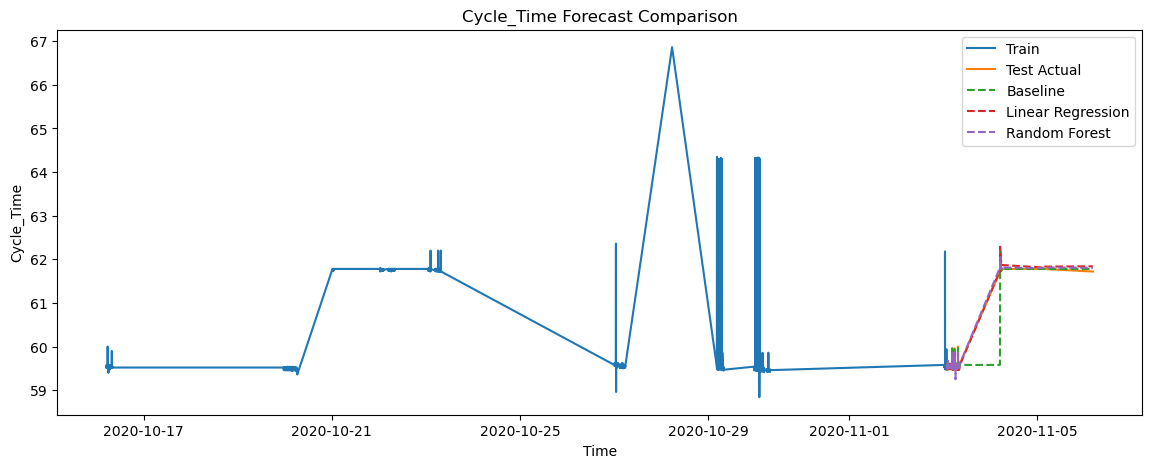

In [29]:
# ---------------------------------------------------------
# 20. 예측 결과 시각화
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(train_df["TimeStamp"], train_df[target_col], label="Train")
plt.plot(test_df["TimeStamp"], y_test.values, label="Test Actual")
plt.plot(test_df["TimeStamp"], baseline_pred.values, label="Baseline", linestyle="--")
plt.plot(test_df["TimeStamp"], linear_pred, label="Linear Regression", linestyle="--")
plt.plot(test_df["TimeStamp"], rf_pred, label="Random Forest", linestyle="--")
plt.title(f"{target_col} Forecast Comparison")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.show()

In [30]:
# ---------------------------------------------------------
# 21. 모델 성능 비교표
# ---------------------------------------------------------
compare_df = pd.DataFrame({
    "model": [
        "Baseline (Previous Value)",
        "Linear Regression",
        "Random Forest Regressor"
    ],
    "MAE": [
        mean_absolute_error(y_test, baseline_pred),
        mean_absolute_error(y_test, linear_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        mean_squared_error(y_test, baseline_pred) ** 0.5,
        mean_squared_error(y_test, linear_pred) ** 0.5,
        mean_squared_error(y_test, rf_pred) ** 0.5
    ],
    "R2": [
        r2_score(y_test, baseline_pred),
        r2_score(y_test, linear_pred),
        r2_score(y_test, rf_pred)
    ]
})

print("=== 모델 성능 비교표 ===")
display(compare_df.sort_values("RMSE"))

=== 모델 성능 비교표 ===


,model,MAE,RMSE,R2
2,Random Forest Regressor,0.011011,0.035502,0.994422
0,Baseline (Previous Value),0.006900,0.062025,0.982976
1,Linear Regression,0.030498,0.062765,0.982567


In [31]:
# ---------------------------------------------------------
# 22. 큰 오차 사례 확인
# ---------------------------------------------------------
error_df = pd.DataFrame({
    "TimeStamp": test_df["TimeStamp"].values,
    "actual": y_test.values,
    "baseline_pred": baseline_pred.values,
    "linear_pred": linear_pred,
    "rf_pred": rf_pred,
    "PassOrFail_binary": test_df["PassOrFail_binary"].values
}, index=test_df.index)

error_df["abs_error_linear"] = (error_df["actual"] - error_df["linear_pred"]).abs()
error_df["abs_error_rf"] = (error_df["actual"] - error_df["rf_pred"]).abs()

print("=== Linear Regression 큰 오차 상위 10개 ===")
display(error_df.sort_values("abs_error_linear", ascending=False).head(10))

print("=== Random Forest 큰 오차 상위 10개 ===")
display(error_df.sort_values("abs_error_rf", ascending=False).head(10))

=== Linear Regression 큰 오차 상위 10개 ===


,TimeStamp,actual,baseline_pred,linear_pred,rf_pred,PassOrFail_binary,abs_error_linear,abs_error_rf
7927,2020-11-04 05:07:28,61.779999,61.779999,62.287901,61.795233,0,0.507902,0.015234
7928,2020-11-04 05:07:28,61.779999,61.779999,62.262388,61.812999,0,0.482389,0.033000
7034,2020-11-03 04:38:22,59.959999,59.520000,59.487858,59.524134,0,0.472141,0.435865
7036,2020-11-03 04:38:22,59.959999,59.959999,59.495303,59.854866,0,0.464696,0.105133
7929,2020-11-04 05:08:28,61.779999,61.779999,62.243815,61.900600,0,0.463816,0.120601
7750,2020-11-03 07:36:56,60.000000,59.520000,59.536878,59.559535,0,0.463122,0.440465
7035,2020-11-03 04:38:22,59.959999,59.959999,59.498838,59.856466,0,0.461161,0.103533
7752,2020-11-03 07:36:56,60.000000,60.000000,59.544771,59.879399,0,0.455229,0.120601
7751,2020-11-03 07:36:56,60.000000,60.000000,59.550180,59.889266,0,0.449820,0.110734
7037,2020-11-03 04:38:22,59.959999,59.959999,59.530490,59.839600,0,0.429509,0.120400


=== Random Forest 큰 오차 상위 10개 ===


,TimeStamp,actual,baseline_pred,linear_pred,rf_pred,PassOrFail_binary,abs_error_linear,abs_error_rf
7750,2020-11-03 07:36:56,60.000000,59.520000,59.536878,59.559535,0,0.463122,0.440465
7034,2020-11-03 04:38:22,59.959999,59.520000,59.487858,59.524134,0,0.472141,0.435865
7318,2020-11-03 05:49:46,59.959999,59.700001,59.550859,59.631134,0,0.409140,0.328865
7450,2020-11-03 06:22:32,59.580002,59.560001,59.543344,59.255267,0,0.036658,0.324735
7451,2020-11-03 06:22:32,59.580002,59.580002,59.542397,59.265001,0,0.037605,0.315001
7453,2020-11-03 06:22:32,59.580002,59.580002,59.541159,59.265001,0,0.038843,0.315001
7452,2020-11-03 06:22:32,59.580002,59.580002,59.539360,59.265001,0,0.040641,0.315001
7449,2020-11-03 06:21:32,59.560001,59.560001,59.568845,59.252001,0,0.008844,0.308001
7448,2020-11-03 06:21:32,59.560001,59.560001,59.571542,59.252001,0,0.011540,0.308001
7447,2020-11-03 06:21:32,59.560001,59.560001,59.573189,59.252001,0,0.013188,0.308001


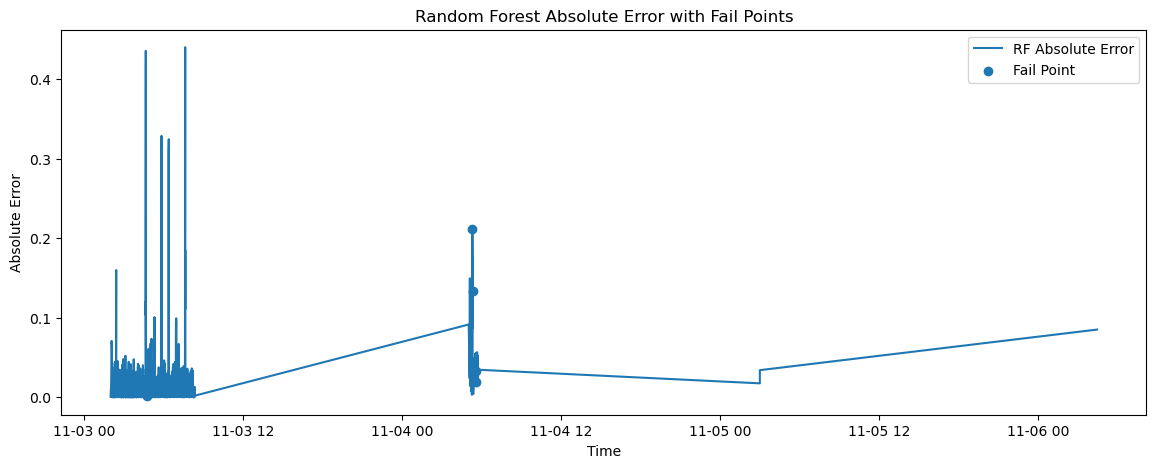

In [32]:
# ---------------------------------------------------------
# 23. 큰 오차와 불량 발생 비교
# ---------------------------------------------------------
plt.figure(figsize=(14, 5))
plt.plot(error_df["TimeStamp"], error_df["abs_error_rf"], label="RF Absolute Error")

fail_error_points = error_df[error_df["PassOrFail_binary"] == 1]
plt.scatter(
    fail_error_points["TimeStamp"],
    fail_error_points["abs_error_rf"],
    label="Fail Point",
    marker="o"
)

plt.title("Random Forest Absolute Error with Fail Points")
plt.xlabel("Time")
plt.ylabel("Absolute Error")
plt.legend()
plt.show()

=== Random Forest 중요 변수 ===


,feature,importance
3,Clamp_Close_Time,0.274862
1,Filling_Time,0.252184
6,Plasticizing_Position,0.248748
11,Max_Injection_Pressure,0.094140
12,Max_Switch_Over_Pressure,0.057519
7,Clamp_Open_Position,0.025378
13,Max_Back_Pressure,0.016355
9,Max_Screw_RPM,0.009200
14,Average_Back_Pressure,0.008173
0,Injection_Time,0.005126


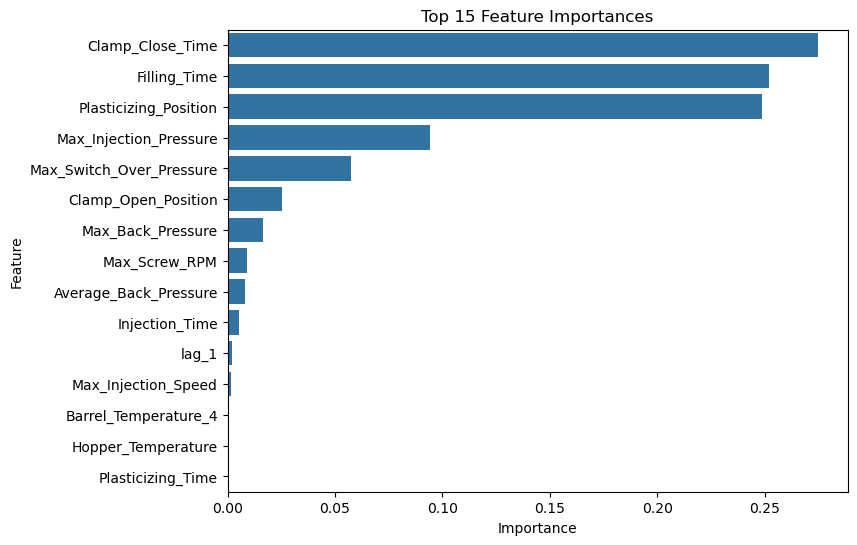

In [33]:
# ---------------------------------------------------------
# 24. Random Forest 중요 변수 확인
# ---------------------------------------------------------
rf_importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("=== Random Forest 중요 변수 ===")
display(rf_importance_df)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [34]:
# ---------------------------------------------------------
# 25. 이상징후 탐색
#    - rolling std가 큰 구간을 단순 이상 후보로 보기
# ---------------------------------------------------------
threshold = df_model["rolling_std_10"].mean() + 2 * df_model["rolling_std_10"].std()
df_model["anomaly_flag"] = (df_model["rolling_std_10"] > threshold).astype(int)

print("=== 이상징후 후보 개수 ===")
display(df_model["anomaly_flag"].value_counts())

=== 이상징후 후보 개수 ===


anomaly_flag
0    7757
1     239
Name: count, dtype: int64

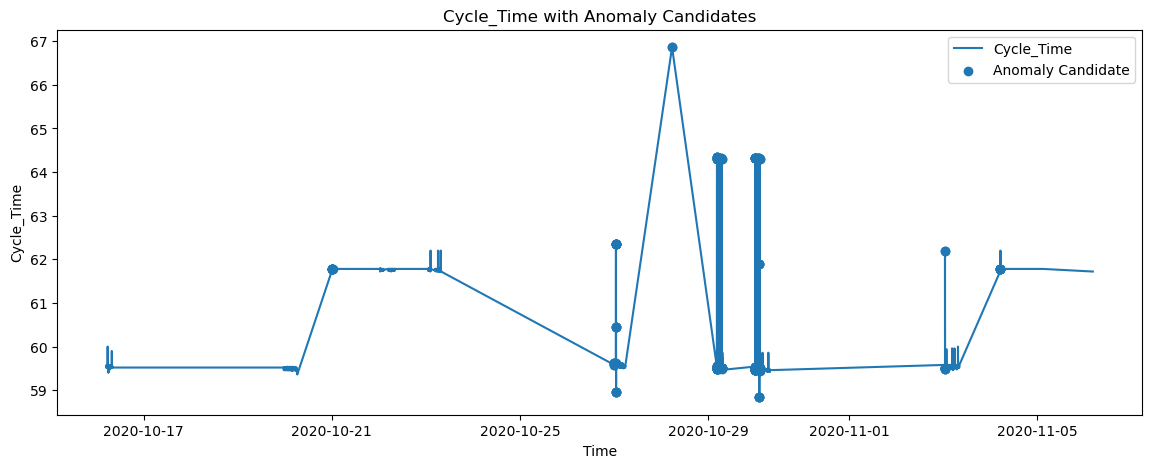

In [35]:
plt.figure(figsize=(14, 5))
plt.plot(df_model["TimeStamp"], df_model[target_col], label=target_col)

anomaly_points = df_model[df_model["anomaly_flag"] == 1]
plt.scatter(
    anomaly_points["TimeStamp"],
    anomaly_points[target_col],
    label="Anomaly Candidate",
    marker="o"
)

plt.title(f"{target_col} with Anomaly Candidates")
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.show()

In [36]:
# ---------------------------------------------------------
# 26. 시간대별 불량 분포
# ---------------------------------------------------------
df_model["hour"] = df_model["TimeStamp"].dt.hour

hourly_fail = df_model.groupby("hour")["PassOrFail_binary"].mean().reset_index()
hourly_fail["fail_ratio_percent"] = hourly_fail["PassOrFail_binary"] * 100

print("=== 시간대별 불량 비율 ===")
display(hourly_fail[["hour", "fail_ratio_percent"]])

=== 시간대별 불량 비율 ===


,hour,fail_ratio_percent
0,0,1.258741
1,1,1.803607
2,2,0.217865
3,3,0.000000
4,4,0.592885
5,5,2.489960
6,6,0.195695
7,7,0.321199
8,8,0.000000
9,23,0.000000


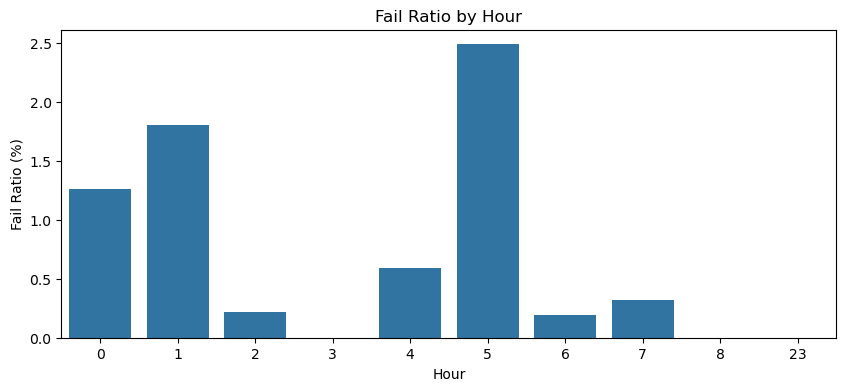

In [37]:
plt.figure(figsize=(10, 4))
sns.barplot(data=hourly_fail, x="hour", y="fail_ratio_percent")
plt.title("Fail Ratio by Hour")
plt.xlabel("Hour")
plt.ylabel("Fail Ratio (%)")
plt.show()

In [38]:
# ---------------------------------------------------------
# 27. 워크숍 질문
# ---------------------------------------------------------
print("\n=== 워크숍 질문 ===")
print("1. 왜 시계열은 랜덤 분할이 아니라 시간순 분할을 해야 할까?")
print("2. Baseline보다 좋은 모델이 무엇이었는가?")
print("3. lag feature와 rolling feature는 어떤 역할을 했는가?")
print("4. 큰 오차 구간과 불량 발생 구간은 겹치는가?")
print("5. 어떤 변수들이 Cycle_Time 예측에 중요했는가?")


=== 워크숍 질문 ===
1. 왜 시계열은 랜덤 분할이 아니라 시간순 분할을 해야 할까?
2. Baseline보다 좋은 모델이 무엇이었는가?
3. lag feature와 rolling feature는 어떤 역할을 했는가?
4. 큰 오차 구간과 불량 발생 구간은 겹치는가?
5. 어떤 변수들이 Cycle_Time 예측에 중요했는가?


In [39]:
# ---------------------------------------------------------
# 28. 6주차 연결 질문
# ---------------------------------------------------------
print("\n=== 다음 시간 생각해볼 질문 ===")
print("- 여러 모델을 조합하면 성능이 더 좋아질까?")
print("- AutoML은 모델 비교를 얼마나 자동화할 수 있을까?")
print("- 시계열/분류/회귀 결과를 발표할 때 어떤 표가 필요할까?")


=== 다음 시간 생각해볼 질문 ===
- 여러 모델을 조합하면 성능이 더 좋아질까?
- AutoML은 모델 비교를 얼마나 자동화할 수 있을까?
- 시계열/분류/회귀 결과를 발표할 때 어떤 표가 필요할까?


In [40]:
# ---------------------------------------------------------
# 29. 최종 정리
# ---------------------------------------------------------
print("\n=== 오늘 실습 정리 ===")
print("1. TimeStamp 기반 시계열 구조를 확인했다.")
print("2. rolling mean / rolling std로 시간 흐름을 봤다.")
print("3. lag / rolling feature를 생성했다.")
print("4. 시간순 train/test split으로 예측 문제를 만들었다.")
print("5. Baseline, Linear Regression, Random Forest를 비교했다.")
print("6. 큰 오차 구간과 PassOrFail 발생 구간을 함께 해석했다.")
print("7. 이상징후 후보와 시간대별 불량 비율도 확인했다.")


=== 오늘 실습 정리 ===
1. TimeStamp 기반 시계열 구조를 확인했다.
2. rolling mean / rolling std로 시간 흐름을 봤다.
3. lag / rolling feature를 생성했다.
4. 시간순 train/test split으로 예측 문제를 만들었다.
5. Baseline, Linear Regression, Random Forest를 비교했다.
6. 큰 오차 구간과 PassOrFail 발생 구간을 함께 해석했다.
7. 이상징후 후보와 시간대별 불량 비율도 확인했다.


In [41]:
# end